# Stellar rotation example

Demonstrates SAJAX's core use case: rotating a spotted star through 360° and computing the broadband light curve and wavelength-dependent contamination factor ε(λ) at each phase.

In [1]:
import os
import sys
import warnings
import numpy as np
import matplotlib.pylab as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
warnings.filterwarnings(action='ignore', category=RuntimeWarning)
import importlib
from sajax import compute_light_curve


## Input spectrum

Load the quiet-photosphere and spot spectra, and the wavelength-dependent limb-darkening coefficients.

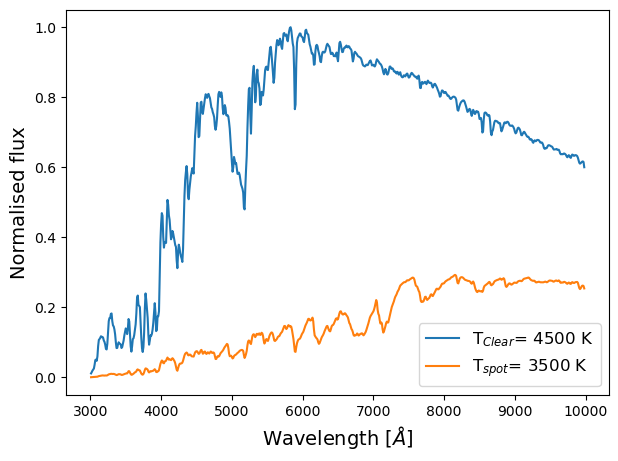

In [2]:
wavelength, flux_hot, flux_cold = np.loadtxt('input_spectrum.txt').T
u1, u2 = np.loadtxt('ldc.txt').T
plt.figure(figsize=(7,5))
plt.plot(wavelength, flux_hot, label=r'T$_{Clear}$= 4500 K')
plt.plot(wavelength, flux_cold, label=r'T$_{spot}$= 3500 K')
plt.xlabel(r'Wavelength [$\AA$]', fontsize=14)
plt.ylabel('Normalised flux', fontsize=14)
plt.legend(fontsize=12)

## Parameters

Define spot geometry, stellar inclination, rotational phase grid, and grid resolution.

In [3]:
stellar_grid_size = 100

# Spot parameters
spot_long = [0, 40]  # in degrees
spot_lat  = [0, 30]  # in degrees
spot_size = [4, 2]   # in degrees
inclination = 90     # in degrees
ve = 0.0             # km/s

params = dict(
    u1       = u1,          # limb-darkening coefficient 1 (per-wavelength array)
    u2       = u2,          # limb-darkening coefficient 2 (per-wavelength array)
    inc_star = inclination, # stellar inclination [deg]
)

Delta_rotAngle = 20  # in degrees
rotational_angle = np.arange(0, 360 + Delta_rotAngle, Delta_rotAngle)

## Compute light curves

Run `compute_light_curve` twice — once with wavelength-dependent limb darkening (`multi-color`) and once without (`single`) — to isolate its effect on ε(λ).

In [4]:
result = compute_light_curve(
    wavelength        = wavelength,
    flux_hot          = flux_hot,
    flux_cold         = flux_cold,
    params            = params,
    spot_lat          = spot_lat,
    spot_long         = spot_long,
    spot_size         = spot_size,
    phases_rot        = rotational_angle,
    stellar_grid_size = stellar_grid_size,
    ve                = ve,
    ldc_mode          = 'multi-color',
)

result_nold = compute_light_curve(
    wavelength        = wavelength,
    flux_hot          = flux_hot,
    flux_cold         = flux_cold,
    params            = params,
    spot_lat          = spot_lat,
    spot_long         = spot_long,
    spot_size         = spot_size,
    phases_rot        = rotational_angle,
    stellar_grid_size = stellar_grid_size,
    ve                = ve,
    ldc_mode          = 'single',
)

flux_norm               = result['lc']
contamination_factors   = result['epsilon']
star_maps               = result['star_maps']

flux_norm_nold             = result_nold['lc']
contamination_factors_nold = result_nold['epsilon']

build_model: multi-wavelength LDCs — using per-wavelength u1/u2 arrays (length 698).


## Contamination factor

Plot ε(λ) at every rotational phase. Each curve shows how much the spot biases a transmission spectrum measurement at that phase.

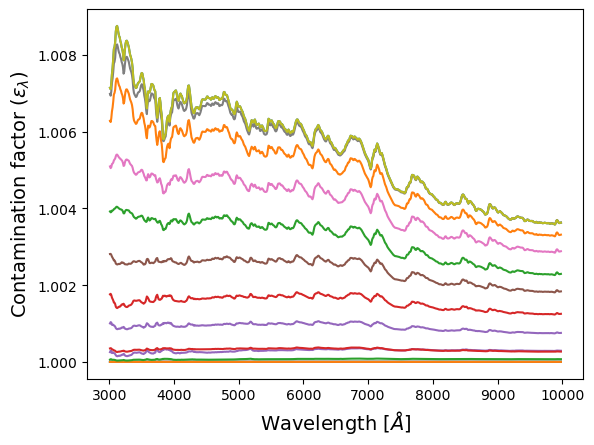

In [5]:
for i in range(len(contamination_factors)):
    plt.plot(wavelength, contamination_factors[i])
    plt.xlabel(r'Wavelength [$\AA$]', fontsize=14)
    plt.ylabel(r'Contamination factor ($\epsilon_{\lambda}$)', fontsize=14)

### Animation

Animate the stellar disc map, broadband light curve, and ε(λ) together as the star rotates. The dashed line shows the no-limb-darkening case for comparison.

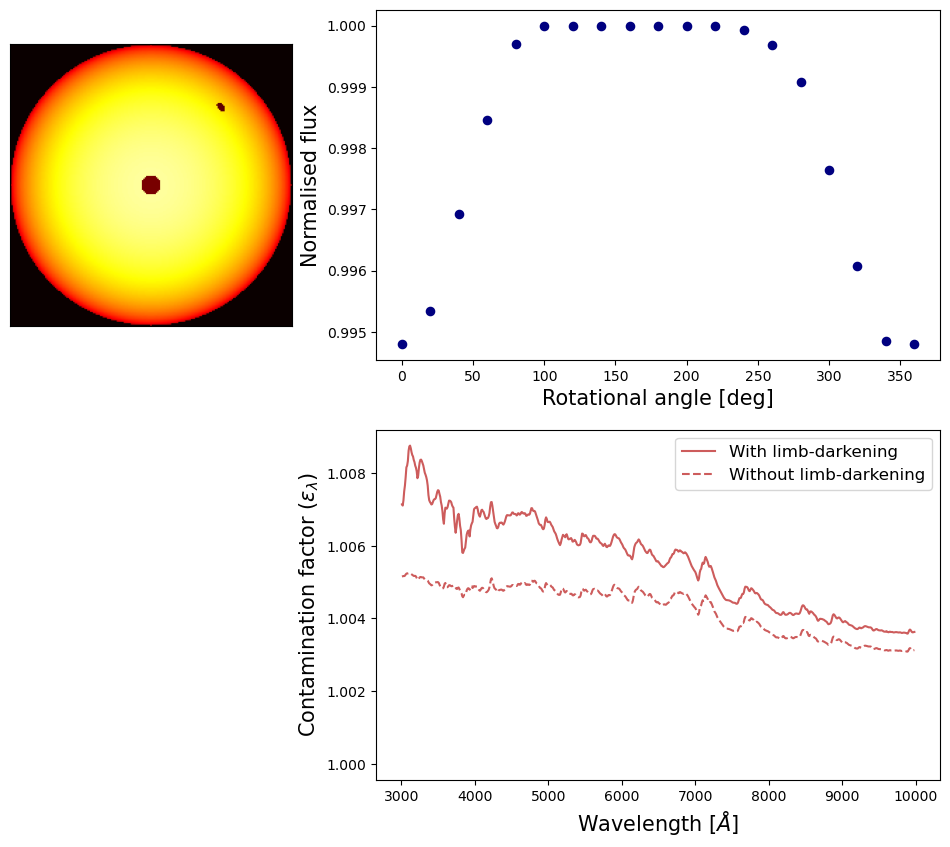

In [6]:
fig = plt.figure(figsize = (12,10))
gs = gridspec.GridSpec(2,2, width_ratios = [0.5, 1], height_ratios = [1, 1])

imgs= []
for i in range(len(rotational_angle)):
    
    # star
    ax0 = plt.subplot(gs[0, 0])   
    img0= ax0.imshow(star_maps[i].T, cmap=cm.hot, origin='lower', vmin=0.0, vmax=1.)
    ax0.set_xticks([])
    ax0.set_yticks([])
    
    # norm flux
    ax1= plt.subplot(gs[0,1])
    img1= ax1.scatter(rotational_angle[0:i+1], flux_norm[0:i+1], color = 'Navy', s = 35)
    ax1.set_xlabel('Rotational angle [deg]', fontsize=15)
    ax1.set_ylabel('Normalised flux', fontsize=15)
    
    # contamination factor
    ax2= plt.subplot(gs[1,1])
    img2,= ax2.plot(wavelength, contamination_factors[i], color = 'indianred', lw=1.5)
    img3,= ax2.plot(wavelength, contamination_factors_nold[i], color= 'indianred', lw=1.5, linestyle='dashed')
    
    ax2.set_xlabel(r'Wavelength [$\AA$]', fontsize=15)
    ax2.set_ylabel(r'Contamination factor ($\epsilon_{\lambda}$)', fontsize=15)
    
    imgs.append([img0, img1, img2, img3])
ax2.plot([], [], color = 'indianred', lw=1.5, label= 'With limb-darkening')
ax2.plot([], [], c='indianred', lw=1.5, label= 'Without limb-darkening', linestyle='dashed')
ax2.legend(fontsize=12)
ani = animation.ArtistAnimation(fig, imgs, interval=300, blit=False, repeat = True, repeat_delay =0)

ani.save(f'rotating_star.gif', dpi= 300)
    
plt.show()